<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Nicolas Cubillos
-Camilo Rendon
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [1]:
### TU CÓDIGO AQUÍ ###
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [3]:
from google.colab import drive, files
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/bases ia'
os.chdir(path)

In [5]:
df = pd.read_csv('Country-data.csv')

2. Muestra las 5 primeras filas

In [6]:
print("Primeras filas:")

df.head()


Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [7]:
print("\nInformación del DataFrame:")

df.info()



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


4. Obtén las estadísticas descriptivas de las variables del dataset

In [8]:
print("\nEstadísticas Descriptivas:")
df.describe()



Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

In [9]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


6. ¿Las escalas de las variables son muy diferentes?

si, se evidencia diferente escala en variables como lo son ingreso, pib per capita

7. ¿Qué implicaciones tiene esto para el análisis de clustering?


Cuando las variables se encuentran en escalas diferentes, aquellas con mayor magnitud tienden a dominar el cálculo de las distancias y, en consecuencia, pueden sesgar la formación de los clusters. Por esta razón, es necesario escalar los datos, de manera que todas las variables tengan una influencia equilibrada en el proceso de agrupamiento.

8. Redacta un análisis de las estadísticas descriptivas

Análisis de variables descriptivas

Estructura y desigualdad económica:
Los datos correspondientes a 167 países evidencian una fuerte desigualdad económica a nivel global. El ingreso per cápita presenta una media de 9,960, lo que sugiere que gran parte de los países se ubica por debajo de ese valor, debido a que un grupo reducido de economías con ingresos muy altos eleva el promedio general. Este mismo comportamiento se observa en el PIB, cuya media es de 4,660, reflejando de manera aún más marcada la concentración de la riqueza en pocas naciones.

Salud y demografía:
En términos demográficos, la esperanza de vida muestra un rango intercuartílico relativamente compacto, entre 65.3 y 76.8 años, lo que indica cierta convergencia internacional en este indicador. No obstante, la mortalidad infantil presenta una dinámica muy distinta: su media de 38.3 casi duplica la mediana de 19.3 y alcanza un valor máximo de 208 por cada 1,000 nacidos vivos, lo que pone en evidencia que existe un grupo de países con condiciones sanitarias y de salud pública particularmente críticas.

Comercio e inflación:
Las variables asociadas al comercio exterior reflejan distintos niveles de apertura económica entre los países analizados. Las importaciones, por ejemplo, registran una media equivalente al 46.9% del ingreso y alcanzan valores de hasta 174%, lo que sugiere la existencia de economías altamente dependientes del comercio internacional. Por su parte, la inflación es una de las variables con mayor dispersión, con valores que van desde -4.21% hasta 104%, mostrando la coexistencia de economías con procesos deflacionarios y otras afectadas por episodios de inflación extrema o hiperinflación. Finalmente, el gasto en salud presenta una media de 6.82% y una dispersión relativamente baja, lo que indica que, pese a las amplias diferencias económicas entre países, la mayoría destina una proporción similar de su ingreso a este sector.

1. Selecciona solo las variables numéricas para el clustering

In [11]:
X = df[['imports', 'exports',"income","inflation","gdpp","child_mort","health","life_expec","total_fer"]]


2. Estandariza las variables usando StandardScaler

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=['imports', 'exports',"income","inflation","gdpp","child_mort","health","life_expec","total_fer"])
X_scaled_df


,imports,exports,income,inflation,gdpp,child_mort,health,life_expec,total_fer
0,-0.08,-1.14,-0.81,0.16,-0.68,1.29,0.28,-1.62,1.90
1,0.07,-0.48,-0.38,-0.31,-0.49,-0.54,-0.10,0.65,-0.86
2,-0.64,-0.10,-0.22,0.79,-0.47,-0.27,-0.97,0.67,-0.04
3,-0.17,0.78,-0.59,1.39,-0.52,2.01,-1.45,-1.18,2.13
4,0.50,0.16,0.10,-0.60,-0.04,-0.70,-0.29,0.70,-0.54
...,...,...,...,...,...,...,...,...,...
162,0.24,0.20,-0.74,-0.49,-0.55,-0.23,-0.57,-0.85,0.37
163,-1.21,-0.46,-0.03,3.62,0.03,-0.53,-0.70,0.55,-0.32
164,1.38,1.13,-0.66,0.41,-0.64,-0.37,0.01,0.29,-0.66
165,-0.52,-0.41,-0.66,1.50,-0.64,0.45,-0.60,-0.34,1.14


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

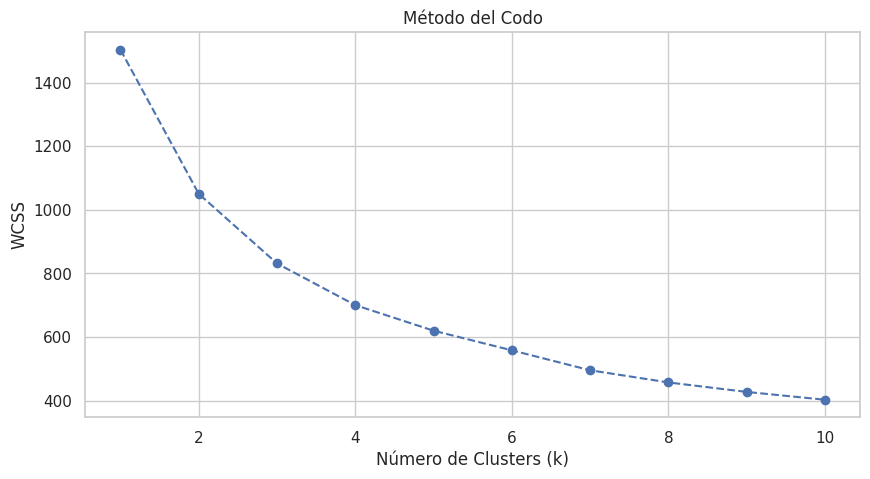

In [13]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.show()


2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

Desde nuestra perspectiva, el número óptimo de clusters corresponde a 5, puesto que después de este punto no se evidencian cambios significativos al incorporar un cluster adicional.

3. Calcula y grafica el coeficiente de silueta

Para n_clusters = 2, el coeficiente de silueta promedio es: 0.2874
Para n_clusters = 3, el coeficiente de silueta promedio es: 0.2833
Para n_clusters = 4, el coeficiente de silueta promedio es: 0.2960
Para n_clusters = 5, el coeficiente de silueta promedio es: 0.2993
Para n_clusters = 6, el coeficiente de silueta promedio es: 0.2287
Para n_clusters = 7, el coeficiente de silueta promedio es: 0.2477
Para n_clusters = 8, el coeficiente de silueta promedio es: 0.2388
Para n_clusters = 9, el coeficiente de silueta promedio es: 0.2073
Para n_clusters = 10, el coeficiente de silueta promedio es: 0.2022


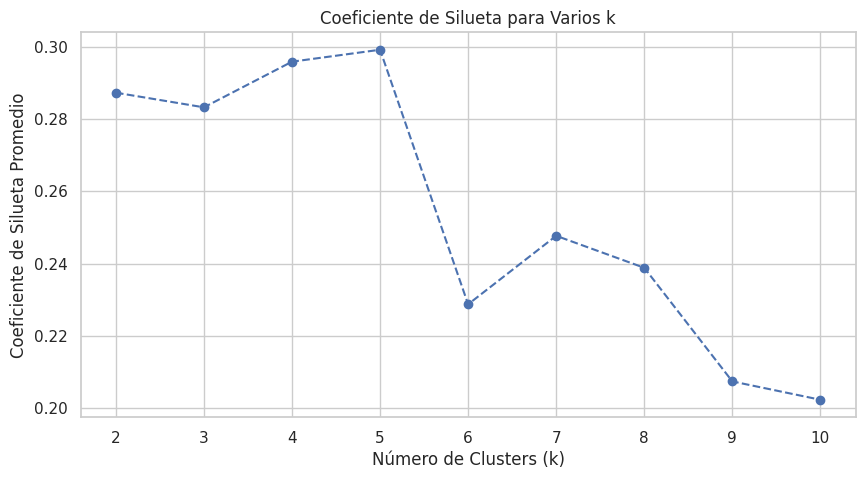

In [14]:
range_n_clusters = range(2, 11)

silhouette_avg_scores = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled_df)
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"Para n_clusters = {n_clusters}, el coeficiente de silueta promedio es: {silhouette_avg:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', linestyle='--')
plt.title('Coeficiente de Silueta para Varios k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

Como se mencionó anteriormente, el número óptimo de clusters parece ser 5, ya que es la configuración que presenta el coeficiente de silueta promedio más alto.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

En un primer momento, se optó por seleccionar cinco clusters con base en una apreciación intuitiva de la gráfica del codo, ya que a partir de ese punto no se observaban reducciones significativas adicionales en la variabilidad dentro de los grupos. Posteriormente, al complementar este criterio con el análisis del coeficiente de silueta promedio, se encontró que la solución de 5 clusters presentaba el valor más alto, con un coeficiente de 0.2993. Esto permite confirmar que dicha partición es la más adecuada, al ser la que ofrece el mejor desempeño según esta métrica de calidad del agrupamiento.

6. Aplica K-Means con el k que tu grupo eligió.

In [15]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_df)
clusters_kmeans


array([1, 0, 0, 1, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 1,
       0, 3, 0, 1, 1, 0, 1, 3, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 3, 3,
       3, 0, 0, 0, 0, 1, 1, 0, 0, 3, 3, 1, 1, 0, 3, 1, 3, 0, 0, 1, 1, 0,
       1, 0, 3, 0, 0, 0, 1, 3, 3, 3, 0, 3, 0, 0, 1, 1, 3, 0, 1, 0, 0, 1,
       1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       3, 3, 1, 4, 3, 0, 1, 0, 0, 0, 0, 0, 3, 3, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 2, 0, 3, 1, 1, 3, 3, 0, 0, 1, 0, 3, 3, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 3, 3, 3, 0, 0, 0, 0, 0, 1, 1], dtype=int32)

7. Añade la asignación de clusters al DataFrame original

In [16]:
df['Cluster_KMeans'] = clusters_kmeans
df


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_KMeans
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,1
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,1
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970,0
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500,0
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310,0
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310,1


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [18]:
df.groupby('Cluster_KMeans')[['imports', 'exports',"income","inflation","gdpp","child_mort","health","life_expec","total_fer"]].mean()

,imports,exports,income,inflation,gdpp,child_mort,health,life_expec,total_fer
Cluster_KMeans,,,,,,,,,
0,47.52,40.98,"12,801.07",7.62,"6,581.81",21.61,6.17,73.00,2.28
1,43.68,29.66,"3,870.70",9.95,"1,900.26",90.79,6.46,59.21,4.97
2,156.67,176.00,"64,033.33",2.47,"57,566.67",4.13,6.79,81.43,1.38
3,40.58,46.12,"44,021.88",2.51,"42,118.75",5.18,9.09,80.08,1.79
4,17.40,25.30,"5,150.00",104.00,"2,330.00",130.00,5.07,60.50,5.84


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

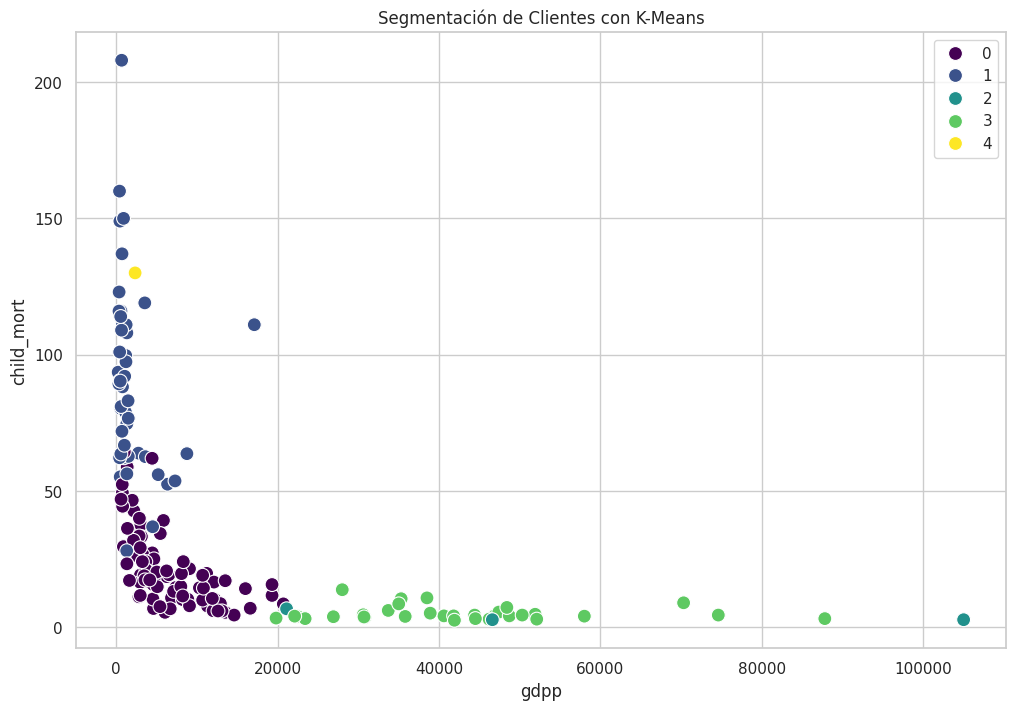

In [17]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='gdpp', y='child_mort', hue='Cluster_KMeans', data=df, palette='viridis', s=100)

# Visualizar los centroides
#centroids = scaler.inverse_transform(kmeans.cluster_centers_)
#plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroides')

plt.title('Segmentación de Clientes con K-Means')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.show()


3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.


Clusters identificados

Cluster 0: Economías en desarrollo intermedio
Cluster 1: Países en desarrollo con alta vulnerabilidad
Cluster 2: Economías desarrolladas de alto comercio
Cluster 3: Países de renta alta consolidada
Cluster 4: Estado frágil en crisis extrema

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.


Grupo 0 = Economías en desarrollo intermedio
Este grupo reúne países con un nivel de ingreso per cápita medio, cercano a 12,801, y un PIB de 6,582. Presentan una mortalidad infantil moderada de 21,6 y una esperanza de vida de 73 años, lo que refleja avances importantes en salud, aunque todavía persisten limitaciones. La tasa de fertilidad de 2.28 muestra que estos países se encuentran próximos al nivel de reemplazo poblacional. En conjunto, corresponden a economías en proceso de transición, que han logrado cierto progreso, pero que aún mantienen brechas relevantes en términos de bienestar y desarrollo.

Grupo 1 = Países en desarrollo con alta vulnerabilidad
Se trata del grupo más amplio dentro de la clasificación observada en el gráfico. Sus países presentan el ingreso per cápita más bajo entre los clusters de mayor tamaño, con 3,871, acompañado de un PIB de 1,900, lo que evidencia escenarios de pobreza estructural. Además, registran una mortalidad infantil muy alta de 90.8, una esperanza de vida reducida de 59 años y una tasa de fertilidad elevada de 4.97. Estas características muestran que aquí se concentran los mayores rezagos y desafíos en materia de desarrollo humano.

Grupo 2 = Economías desarrolladas con alta apertura comercial
Este grupo se caracteriza por niveles muy elevados de PIB e ingreso, con valores de 57,567 y 64,033, respectivamente, así como por una mortalidad infantil muy baja de apenas 4,1. Su rasgo más distintivo es la fuerte inserción en el comercio internacional, reflejada en tasas de importaciones de 156,7% y exportaciones de 176%, lo que sugiere economías pequeñas, altamente abiertas y muy competitivas, como podrían ser Singapur o Luxemburgo. También destacan por una esperanza de vida alta, de 81,4 años, y una fertilidad reducida de 1,38.

Grupo 3 = Países de renta alta consolidada
Aquí se ubican economías con altos niveles de ingreso y producción, con un PIB de 42,119 y un ingreso per cápita de 44,022. Presentan una mortalidad infantil muy baja de 5.2 y una esperanza de vida de 80 años, indicadores propios de sociedades con altos estándares de vida. A diferencia del Grupo 2, su participación en el comercio exterior es más moderada, con valores entre 40% y 46%, lo que sugiere economías de mayor tamaño y con mercados internos más sólidos. Además, registran el mayor gasto en salud, con 9,09%, lo que es consistente con estados de bienestar más desarrollados.

Grupo 4 = Estado frágil en crisis extrema
Este cluster está conformado por un solo país, representado como un punto amarillo en el gráfico, y constituye un caso claramente atípico. Se distingue por exhibir la mortalidad infantil más alta de todos los grupos, con 130, junto con una inflación extremadamente elevada de 104%, un ingreso de 5,150 y una esperanza de vida de apenas 60.5 años. La combinación de deterioro económico severo y crisis humanitaria profunda lo convierte en un caso excepcional, que demanda un análisis particular y medidas urgentes.

5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

Recomendación de política pública
El cluster más adecuado para una intervención prioritaria del PNUD es el Grupo 1: países en desarrollo con alta vulnerabilidad, ya que concentra los mayores rezagos en desarrollo humano, reflejados en bajos niveles de ingreso, alta mortalidad infantil, reducida esperanza de vida y elevada fertilidad. Frente a este panorama, una estrategia pertinente sería la implementación de un programa de inversión integrada en capital humano temprano.

Este programa podría estructurarse a partir de transferencias condicionadas dirigidas a los hogares más vulnerables, inspiradas en experiencias exitosas como Bolsa Família en Brasil y Oportunidades/Prospera en México, pero ajustadas a las realidades institucionales y sociales de los países africanos y asiáticos donde se concentra este cluster. La finalidad sería romper la transmisión intergeneracional de la pobreza mediante intervenciones simultáneas en salud, educación y fortalecimiento institucional.

En el componente de salud, el programa otorgaría subsidios monetarios condicionados al cumplimiento de controles prenatales, esquemas completos de vacunación infantil y asistencia periódica a centros de salud. Con ello, se buscaría impactar de manera directa uno de los problemas más críticos del grupo: la elevada mortalidad infantil, que alcanza 90.8.

En cuanto a la educación, la política incluiría incentivos económicos para asegurar la permanencia de niñas y niños en la educación primaria. Esta medida no solo elevaría la acumulación de capital humano, sino que también podría generar efectos positivos de mediano y largo plazo, como la reducción de la fertilidad, una mayor participación laboral futura y mejores niveles de ingreso.

Por último, el eje de capacidad institucional sería fundamental para garantizar la efectividad de la intervención. Más allá de aumentar recursos, el PNUD podría apoyar el fortalecimiento de los sistemas locales de salud pública y de gestión social, ya que el gasto en salud observado actualmente no parece traducirse en buenos resultados. Esto sugiere que el problema no radica únicamente en la cantidad de recursos disponibles, sino también en limitaciones de eficiencia, cobertura y acceso.